# Q1.1

In [2]:
import numpy as np
a=np.linspace(0,20,100)
print(a)

[ 0.          0.2020202   0.4040404   0.60606061  0.80808081  1.01010101
  1.21212121  1.41414141  1.61616162  1.81818182  2.02020202  2.22222222
  2.42424242  2.62626263  2.82828283  3.03030303  3.23232323  3.43434343
  3.63636364  3.83838384  4.04040404  4.24242424  4.44444444  4.64646465
  4.84848485  5.05050505  5.25252525  5.45454545  5.65656566  5.85858586
  6.06060606  6.26262626  6.46464646  6.66666667  6.86868687  7.07070707
  7.27272727  7.47474747  7.67676768  7.87878788  8.08080808  8.28282828
  8.48484848  8.68686869  8.88888889  9.09090909  9.29292929  9.49494949
  9.6969697   9.8989899  10.1010101  10.3030303  10.50505051 10.70707071
 10.90909091 11.11111111 11.31313131 11.51515152 11.71717172 11.91919192
 12.12121212 12.32323232 12.52525253 12.72727273 12.92929293 13.13131313
 13.33333333 13.53535354 13.73737374 13.93939394 14.14141414 14.34343434
 14.54545455 14.74747475 14.94949495 15.15151515 15.35353535 15.55555556
 15.75757576 15.95959596 16.16161616 16.36363636 16

In [3]:
print(np.mean(a))
print(np.std(a))
print(np.var(a))

10.0
5.831529302570125
34.00673400673401


# Q1.2

In [7]:
arr = np.arange(1, 37)
print(arr)
print(arr.shape)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36]
(36,)


In [8]:
mat = arr.reshape(4, 9)
print(mat)
print(mat.shape)

[[ 1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18]
 [19 20 21 22 23 24 25 26 27]
 [28 29 30 31 32 33 34 35 36]]
(4, 9)


In [9]:
flat=mat.flatten()
print(flat)
print(flat.shape)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36]
(36,)


# Q2.1

In [2]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset('titanic')

In [11]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [13]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Q2.2

In [22]:
missing_count = df.isnull().sum()
missing_percent = df.isnull().sum() / len(df) * 100
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': df.isnull().sum() / len(df) * 100
})
missing_summary = missing_summary[
    missing_summary['Missing Count'] > 0
]
print(missing_summary)

             Missing Count  Missing Percentage
age                    177           19.865320
embarked                 2            0.224467
deck                   688           77.216611
embark_town              2            0.224467


In [28]:
df['age'] = df.groupby('pclass')['age'].transform(
    lambda x: x.fillna(x.median())
)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [29]:
df['embarked'] = df['embarked'].fillna(
    df['embarked'].mode()[0]
)

In [30]:
df.drop('deck', axis=1, inplace=True)

### Observation

The deck column contains a very high percentage of missing values. Since most entries are unavailable, imputing them would be unreliable. Therefore, the column was removed from the dataset.

In [31]:
print(df[['age', 'embarked']].isnull().sum())

age         0
embarked    0
dtype: int64


# Q3.1

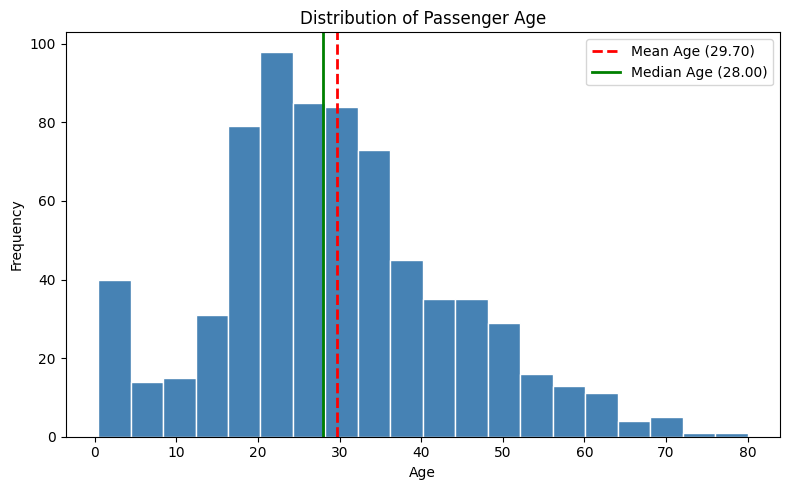

In [3]:
import matplotlib.pyplot as plt

mean_age = df['age'].mean()
median_age = df['age'].median()

plt.figure(figsize=(8, 5))

plt.hist(
    df['age'],
    bins=20,
    color='steelblue',
    edgecolor='white'
)

# Mean line
plt.axvline(
    mean_age,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean Age ({mean_age:.2f})'
)

# Median line
plt.axvline(
    median_age,
    color='green',
    linewidth=2,
    label=f'Median Age ({median_age:.2f})'
)

plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# Q3.2

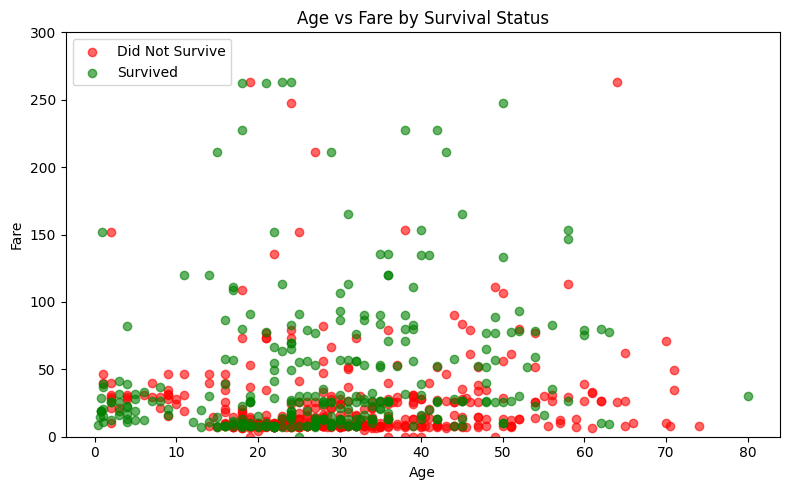

In [4]:
import matplotlib.pyplot as plt

# Separate passengers by survival status
survived = df[df['survived'] == 1]
not_survived = df[df['survived'] == 0]

plt.figure(figsize=(8, 5))

# Died
plt.scatter(
    not_survived['age'],
    not_survived['fare'],
    color='red',
    alpha=0.6,
    label='Did Not Survive'
)

# Survived
plt.scatter(
    survived['age'],
    survived['fare'],
    color='green',
    alpha=0.6,
    label='Survived'
)

plt.title('Age vs Fare by Survival Status')
plt.xlabel('Age')
plt.ylabel('Fare')

# Cap y-axis at 300
plt.ylim(0, 300)

plt.legend()
plt.tight_layout()
plt.show()

### Observation

The fare axis was capped at 300 to reduce the effect of extreme outliers and improve the readability of the scatter plot. A small number of passengers paid exceptionally high fares, which would otherwise compress most data points into a narrow region of the graph.

# Q5.1

In [10]:
import numpy as np
import pandas as pd

# Load dataset
df = pd.read_csv('advertising.csv')

# Feature and target
X = df['TV']
y = df['Sales']

# Train-test split
X_train = X[:160]
X_test = X[160:]

y_train = y[:160]
y_test = y[160:]

# Means
x_bar = np.mean(X_train)
y_bar = np.mean(y_train)

# Slope
m = np.sum((X_train - x_bar) * (y_train - y_bar)) / \
    np.sum((X_train - x_bar) ** 2)

# Intercept
b = y_bar - m * x_bar

print("Slope (m):", m)
print("Intercept (b):", b)

# Predictions
y_pred = m * X_test + b

# Manual MSE
mse = np.mean((y_test - y_pred) ** 2)

print("MSE:", mse)

Slope (m): 0.05572601895005874
Intercept (b): 6.993686960994353
MSE: 5.459799471482253


# Q5.2

In [11]:
from sklearn.model_selection import train_test_split

X = df[['TV']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 0.0554829439314632
Intercept: 7.007108428241848


The coefficient and intercept are close to the values obtained in Q5.1. Small differences occur because Q5.1 used the first 160 rows as the training set, whereas Q5.2 uses a random 80–20 split. Since the model is trained on different observations, the learned parameters are not exactly identical.

# Q6.1

In [18]:
import pandas as pd

df = pd.read_csv('Mall_Customers.csv')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


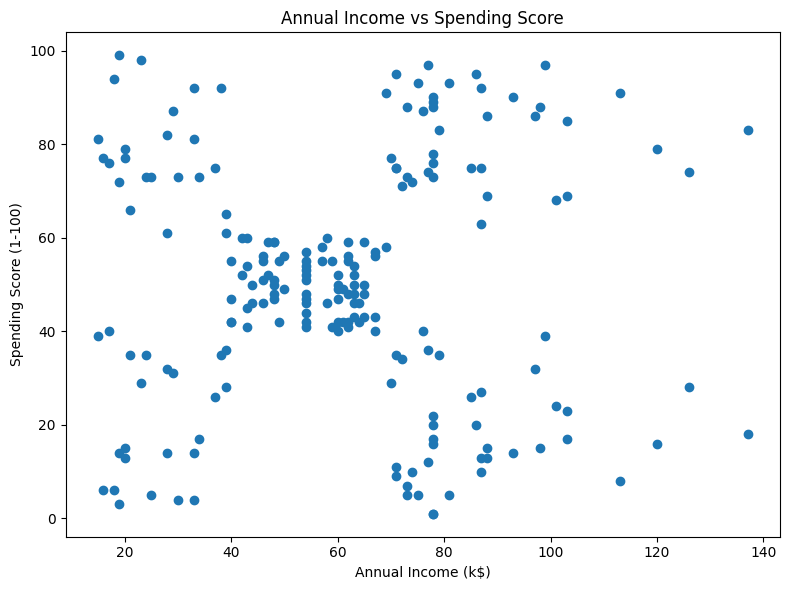

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)']
)

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()

# Q6.2